using age_depth_harmonica

In [68]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import pygmt

import boule as bl
import verde as vd
import harmonica as hm
from numba import njit

In [77]:
d_load = pd.read_csv('..\\..\\created_data\\trimmed_Hcc_ECM1.csv', sep=',', skiprows=1, 
                 names=['num','lon', 'lat', 'z'])
print(d_load)


      num    lon   lat        z
0   15171 -129.5  47.5   9.8547
1   15172 -128.5  47.5  11.2656
2   15173 -127.5  47.5  12.1047
3   15174 -126.5  47.5  12.9090
4   15531 -129.5  46.5   8.0057
5   15532 -128.5  46.5   7.4464
6   15533 -127.5  46.5   6.4545
7   15534 -126.5  46.5   5.9759
8   15891 -129.5  45.5   6.9973
9   15892 -128.5  45.5   6.5795
10  15893 -127.5  45.5   6.7844
11  15894 -126.5  45.5   7.6395
12  16251 -129.5  44.5   6.8513
13  16252 -128.5  44.5   6.5767
14  16253 -127.5  44.5   6.4195
15  16254 -126.5  44.5   7.2499


In [70]:
df = d_load.drop(columns='num')

In [71]:
df.head()

,lon,lat,z
0,-129.5,47.5,9.8547
1,-128.5,47.5,11.2656
2,-127.5,47.5,12.1047
3,-126.5,47.5,12.9090
4,-129.5,46.5,8.0057


In [72]:
ellipsoid = bl.WGS84

a = ellipsoid.semimajor_axis
b = ellipsoid.semiminor_axis
mean_radius = (2 * a + b) / 3

In [73]:
bottom = ellipsoid.mean_radius - 10e3
top = ellipsoid.mean_radius

print(df['lon'].min(), df['lon'].max(), df['lat'].min(), df['lat'].max())

region=df['lon'].min(), df['lon'].max(), df['lat'].min(), df['lat'].max()
spacing=0.01  # number of pnts in each S-N and W-E direction, adjust based on data density

-129.5 -126.5 44.5 47.5


In [74]:
@njit
def density(radius):
    """Linear density function"""
    top = mean_radius
    bottom = mean_radius - 10e3
    density_top = 2670
    density_bottom = 3000
    slope = (density_top - density_bottom) / (top - bottom)
    return slope * (radius - bottom) + density_bottom

## making a depth tesseroid now...

In [75]:
block_reduce = pygmt.blockmedian(x=df['lon'], y=df['lat'], z=df['z'],   # or whatever column you want gridded
    region=region,
    spacing=spacing)

# interpolate onto a continuous grid
hcc_grid = pygmt.surface(data=block_reduce, region=region, spacing=spacing)

print(hcc_grid.head())

<xarray.DataArray 'z' (y: 5, x: 5)> Size: 100B
array([[6.8513   , 6.847073 , 6.842856 , 6.838653 , 6.8344684],
       [6.8502464, 6.846069 , 6.841898 , 6.837738 , 6.8335934],
       [6.849202 , 6.845071 , 6.8409443, 6.8368263, 6.832721 ],
       [6.8481727, 6.8440843, 6.839999 , 6.835922 , 6.8318553],
       [6.8471613, 6.843113 , 6.8390675, 6.835028 , 6.8309984]],
      dtype=float32)
Coordinates:
  * y        (y) float64 40B 44.5 44.51 44.52 44.53 44.54
  * x        (x) float64 40B -129.5 -129.5 -129.5 -129.5 -129.5
Attributes:
    Conventions:   CF-1.7
    title:         Data gridded with continuous surface splines in tension
    history:       gmt surface @GMTAPI@-S-I-D-V-T-N-000000 -G@GMTAPI@-S-O-G-G...
    description:   
    actual_range:  [nan nan]
    long_name:     z


frame:
- a: annotate
- f: frame tick
- g: grid lines

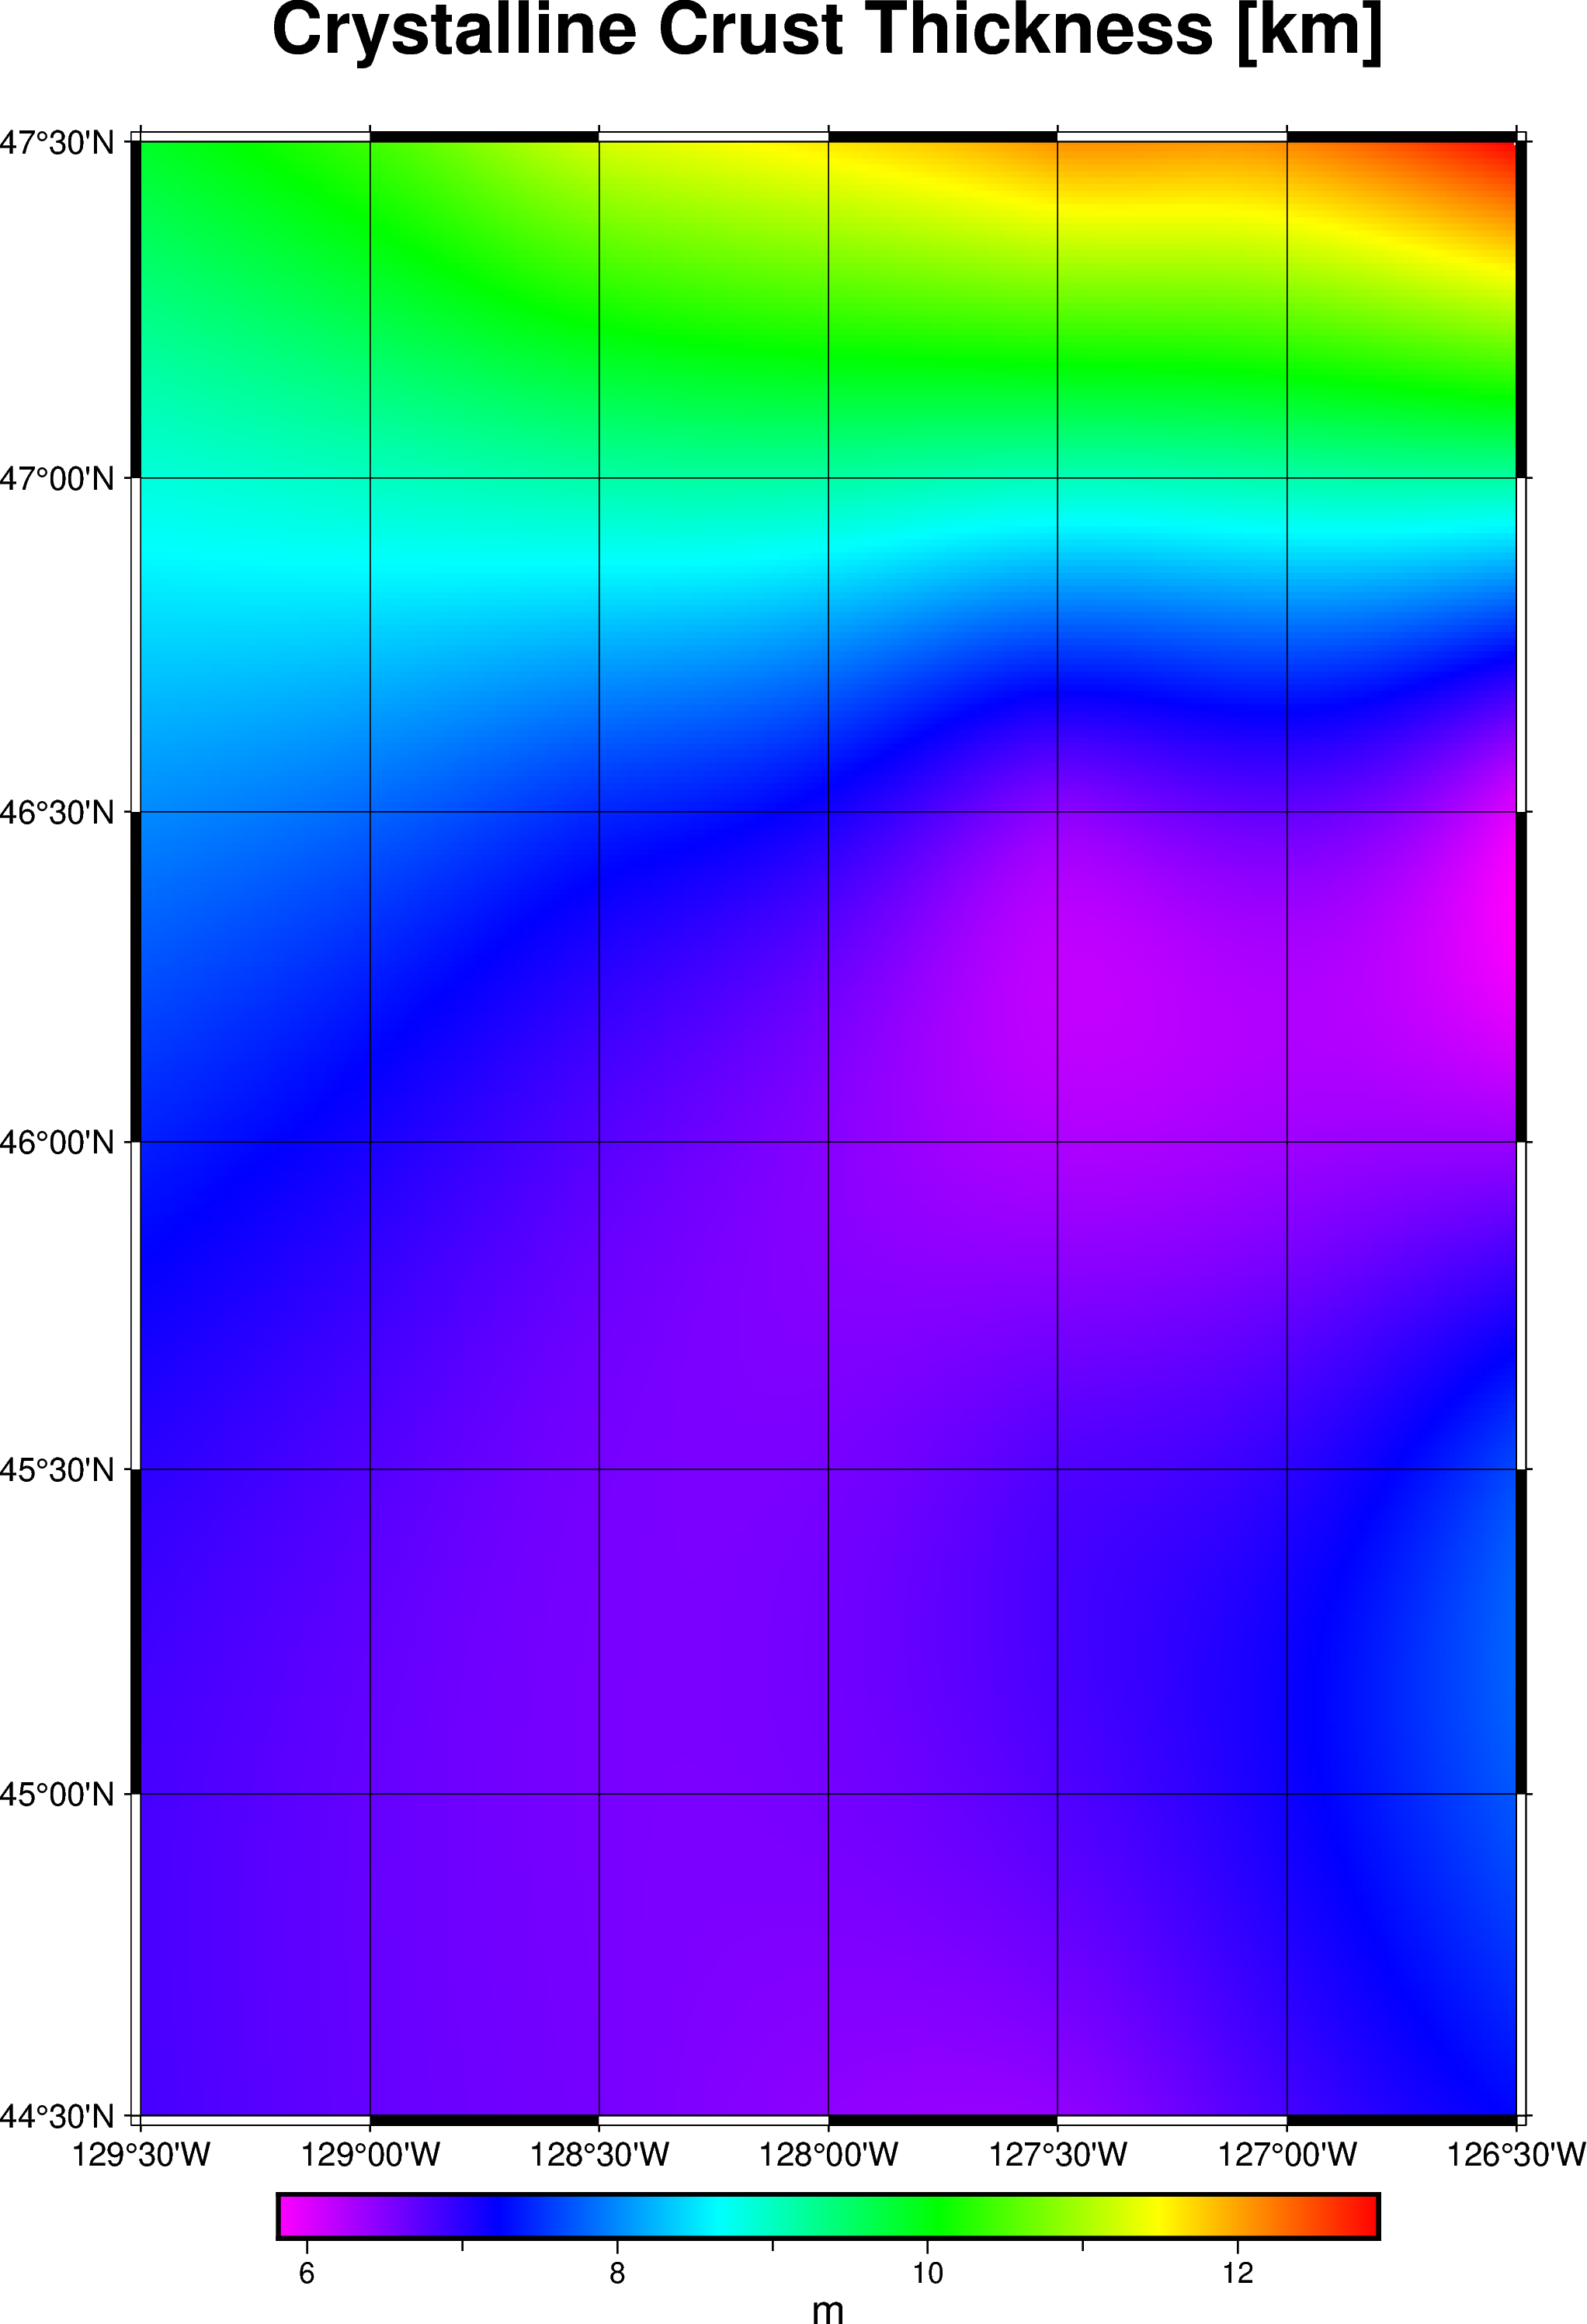

In [78]:
fig1 = pygmt.Figure()
title = 'Crystalline Crust Thickness [km]'

pygmt.makecpt(cmap='rainbow', series=[hcc_grid.min().values, hcc_grid.max().values])

fig1.grdimage(grid=hcc_grid, cmap=True, region=region, projection='M15c', frame=['ag0.5', f'+t{title}'])
fig1.colorbar(cmap=True, frame=['a2f1', 'x+lm'])
# fig1.plot(data='..\\..\\data\\Plate_Boundaries.shp\\Plate_Boundaries.shp', pen='0.5p,red')
# fig1.coast(land='green', transparency=50, shorelines='0.5p,darkgreen')


fig1.savefig('..\\..\\figures\\ecm1\\oct5_ecm1.png', dpi=400, crop='0.5c')  # crop to put whitespace around when i save it
fig1.show()